In [44]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho base dos datasets do Titanic


In [45]:
DATASETS_DIR = Path("/")

# Leitura de CSV em lista de dicionários


In [46]:
def read_csv(file_path):
    file_path = Path(file_path)
    with file_path.open("r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        rows = [row for row in reader]
    return rows, reader.fieldnames

# Funções para limpeza de dados


In [47]:
# Verifica se valor está ausente
def is_missing(value):
    return value is None or value == ""


# Conversão segura para float
def to_float(value):
    if is_missing(value):
        return None
    try:
        return float(value)
    except ValueError:
        return None


# Conversão segura para int
def to_int(value):
    if is_missing(value):
        return None
    try:
        return int(float(value))
    except ValueError:
        return None


# Relatório de ausências por coluna
def missing_report(rows, columns):
    report = {}
    for col in columns:
        report[col] = sum(1 for r in rows if is_missing(r.get(col)))
    return report


# Estatísticas básicas das colunas numéricas
def numeric_summary(rows, columns):
    summary = {}
    for col in columns:
        values = [to_float(r.get(col)) for r in rows]
        values = np.array([v for v in values if v is not None], dtype=float)
        if values.size == 0:
            summary[col] = {"count": 0, "mean": None, "std": None, "min": None, "max": None}
        else:
            summary[col] = {
                "count": int(values.size),
                "mean": float(values.mean()),
                "std": float(values.std(ddof=0)),
                "min": float(values.min()),
                "max": float(values.max()),
            }
    return summary


# Frequências das colunas categóricas
def categorical_summary(rows, columns, top_k=5):
    summary = {}
    for col in columns:
        counts = {}
        for r in rows:
            val = r.get(col)
            if is_missing(val):
                continue
            counts[val] = counts.get(val, 0) + 1
        top = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:top_k]
        summary[col] = top
    return summary


# Distribuição do rótulo
def label_balance(rows, label_col="Survived"):
    counts = {}
    for r in rows:
        val = r.get(label_col)
        if is_missing(val):
            continue
        counts[val] = counts.get(val, 0) + 1
    return counts

# Correlação entre colunas numéricas e o rótulo


In [48]:
def numeric_correlation_with_label(rows, feature_names, fill_values):
    X = np.array([encode_row(r, fill_values) for r in rows], dtype=float)
    corr = np.corrcoef(X, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        xticklabels=feature_names,
        yticklabels=feature_names,
        cmap="coolwarm",
        annot=True,
        fmt=".2f",
    )
    plt.title("Matriz de Correlação entre Atributos")
    plt.tight_layout()
    plt.show()

    return corr

# Valores de preenchimento calculados a partir do treino


In [49]:
def compute_fill_values(rows):
    age_vals = [to_float(r.get("Age")) for r in rows]
    fare_vals = [to_float(r.get("Fare")) for r in rows]
    age_vals = [v for v in age_vals if v is not None]
    fare_vals = [v for v in fare_vals if v is not None]
    sex_vals = [r.get("Sex") for r in rows if not is_missing(r.get("Sex"))]
    emb_vals = [r.get("Embarked") for r in rows if not is_missing(r.get("Embarked"))]
    age_median = float(np.median(age_vals)) if age_vals else 0.0
    fare_median = float(np.median(fare_vals)) if fare_vals else 0.0
    sex_mode = max(set(sex_vals), key=sex_vals.count) if sex_vals else "male"
    emb_mode = max(set(emb_vals), key=emb_vals.count) if emb_vals else "S"
    return {"Age": age_median, "Fare": fare_median, "Sex": sex_mode, "Embarked": emb_mode}

# Mineração do dataset: ausências, estatísticas, categorias, balanceamento e correlação


In [50]:
def mine_titanic_data(base_dir=DATASETS_DIR):
    train_rows, train_cols = read_csv(Path(base_dir) / "train.csv")
    numeric_cols = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
    categorical_cols = ["Sex", "Embarked"]
    feature_names = ["Pclass", "Age", "Fare", "SibSp", "Parch", "Sex", "Embarked"]
    fill_values = compute_fill_values(train_rows)
    return {
        "missing": missing_report(train_rows, train_cols),
        "numeric": numeric_summary(train_rows, numeric_cols),
        "categorical": categorical_summary(train_rows, categorical_cols),
        "label_balance": label_balance(train_rows, "Survived"),
        "corr_matrix": numeric_correlation_with_label(train_rows, feature_names, fill_values),
        "corr_features": feature_names,
    }

# Codifica uma linha em vetor numérico com imputação


In [51]:
def encode_row(row, fill_values):
    age = to_float(row.get("Age"))
    fare = to_float(row.get("Fare"))
    sibsp = to_int(row.get("SibSp"))
    parch = to_int(row.get("Parch"))
    pclass = to_int(row.get("Pclass"))

    age = fill_values["Age"] if age is None else age
    fare = fill_values["Fare"] if fare is None else fare
    sibsp = 0 if sibsp is None else sibsp
    parch = 0 if parch is None else parch
    pclass = 0 if pclass is None else pclass

    sex = row.get("Sex") if not is_missing(row.get("Sex")) else fill_values["Sex"]
    emb = row.get("Embarked") if not is_missing(row.get("Embarked")) else fill_values["Embarked"]

    sex_val = 1 if sex == "female" else 0
    emb_map = {"S": 0, "C": 1, "Q": 2}
    emb_val = emb_map.get(emb, emb_map[fill_values["Embarked"]])

    return [pclass, age, fare, sibsp, parch, sex_val, emb_val]


# Matriz de correlação e remoção de atributos redundantes


In [52]:
def correlation_matrix_and_prune(X, feature_names, threshold=0.8):
    corr = np.corrcoef(X, rowvar=False)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)

    n = corr.shape[0]
    removed = set()
    for i in range(n):
        if i in removed:
            continue
        for j in range(i + 1, n):
            if j in removed:
                continue
            if abs(corr[i, j]) > threshold:
                removed.add(j)

    keep_idx = [i for i in range(n) if i not in removed]
    pruned_X = X[:, keep_idx]
    pruned_features = [feature_names[i] for i in keep_idx]
    removed_features = [feature_names[i] for i in sorted(removed)]

    return corr, pruned_X, pruned_features, removed_features


# Limpeza completa: imputação, codificação e remoção por correlação


In [53]:
def clean_titanic_data(base_dir=DATASETS_DIR):
    train_rows, _ = read_csv(Path(base_dir) / "train.csv")
    test_rows, _ = read_csv(Path(base_dir) / "test.csv")

    fill_values = compute_fill_values(train_rows)
    feature_names = ["Pclass", "Age", "Fare", "SibSp", "Parch", "Sex", "Embarked"]

    X_train = np.array([encode_row(r, fill_values) for r in train_rows], dtype=float)
    y_train = np.array([to_int(r.get("Survived")) for r in train_rows], dtype=int)
    X_test = np.array([encode_row(r, fill_values) for r in test_rows], dtype=float)

    corr, X_train_pruned, pruned_features, removed_features = correlation_matrix_and_prune(
        X_train, feature_names, threshold=0.8
    )
    X_test_pruned = X_test[:, [feature_names.index(f) for f in pruned_features]]

    return {
        "X_train": X_train_pruned,
        "y_train": y_train,
        "X_test": X_test_pruned,
        "feature_names": pruned_features,
        "fill_values": fill_values,
        "corr_matrix": corr,
        "removed_features": removed_features,
    }


# Implementação MLP Classifier

In [54]:
np.random.seed(42)

Funções Sigmoid, Derivada Sigmoid e Binary Cross Entropy

In [55]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def binary_cross_entropy(y_true, y_pred, epsilon=1e-15):
    # Loss para classificação binária com estabilidade numérica
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [56]:
class MLPClassifier:
    def __init__(self, input_dim, hidden_dims, output_dim=1, seed=0, dropout_rate=0.2, l2_lambda=1e-4):
        rng = np.random.default_rng(seed)
        self.weights = []
        self.biases = []
        self.dropout_rate = dropout_rate
        self.l2_lambda = l2_lambda

        # Define as dimensões das camadas
        dims = [input_dim] + hidden_dims + [output_dim]
        for i in range(len(dims) - 1):
            limit = np.sqrt(6 / (dims[i] + dims[i+1]))
            W = rng.uniform(-limit, limit, size=(dims[i], dims[i+1]))
            b = np.zeros((1, dims[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    def forward(self, X, training=False):
        self.activations = [X]
        self.z_values = []
        self.dropout_masks = []

        A = X
        for i in range(len(self.weights) - 1):
            Z = A @ self.weights[i] + self.biases[i]
            A = np.tanh(Z)
            # Dropout apenas no treino
            if training and self.dropout_rate > 0:
                mask = (np.random.rand(*A.shape) > self.dropout_rate).astype(float)
                A = A * mask / (1.0 - self.dropout_rate)
            else:
                mask = None
            self.z_values.append(Z)
            self.activations.append(A)
            self.dropout_masks.append(mask)

        Z_out = A @ self.weights[-1] + self.biases[-1]
        A_out = sigmoid(Z_out)
        self.z_values.append(Z_out)
        self.activations.append(A_out)

        return A_out

    def predict(self, X):
        return self.forward(X, training=False)

    def predict_classes(self, X, threshold=0.5):
        return (self.predict(X) >= threshold).astype(int)

    def fit(self, X_train, y_train, X_val, y_val, epochs=1000, lr=0.01, batch_size=32, early_stopping_patience=20, min_delta=1e-4):
        n_samples = X_train.shape[0]
        train_losses = []
        val_losses = []

        y_train = y_train.reshape(-1, 1)
        y_val = y_val.reshape(-1, 1)
        # Controle de early stopping
        best_val_loss = float("inf")
        best_weights = None
        best_biases = None
        patience_counter = 0

        for epoch in range(epochs):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                y_pred = self.forward(X_batch, training=True)

                error = y_pred - y_batch

                deltas = [error]

                for j in range(len(self.weights) - 2, -1, -1):
                    delta = (deltas[-1] @ self.weights[j+1].T) * (1 - self.activations[j+1]**2)
                    mask = self.dropout_masks[j]
                    if mask is not None:
                        delta = delta * mask / (1.0 - self.dropout_rate)
                    deltas.append(delta)

                deltas.reverse()

                for j in range(len(self.weights)):
                    grad_W = self.activations[j].T @ deltas[j] / X_batch.shape[0]
                    grad_b = np.sum(deltas[j], axis=0, keepdims=True) / X_batch.shape[0]

                    grad_W += self.l2_lambda * self.weights[j]
                    self.weights[j] -= lr * grad_W
                    self.biases[j] -= lr * grad_b

            train_loss = binary_cross_entropy(y_train, self.forward(X_train, training=False))
            val_loss = binary_cross_entropy(y_val, self.forward(X_val, training=False))

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                best_weights = [w.copy() for w in self.weights]
                best_biases = [b.copy() for b in self.biases]
                patience_counter = 0
            else:
                patience_counter += 1

            if epoch % 100 == 0:
                print(f"Epoch {epoch}: Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}")

            if patience_counter >= early_stopping_patience:
                break

        # Restaura os melhores pesos
        if best_weights is not None:
            self.weights = best_weights
            self.biases = best_biases

        return train_losses, val_losses

In [57]:
def standardize(X_train, X_val, X_test):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)
    std[std == 0] = 1.0

    X_train_norm = (X_train - mean) / std
    X_val_norm = (X_val - mean) / std
    X_test_norm = (X_test - mean) / std

    return X_train_norm, X_val_norm, X_test_norm

# Matriz de Confusão

In [58]:
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return np.array([[tn, fp], [fn, tp]])

def plot_confusion_matrix(cm, classes=["Morreu", "Sobreviveu"]):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Matriz de Confusão")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Real')
    plt.xlabel('Predito')
    plt.show()

# Rede treinada e resultados

=== Mineração e Análise de Dados ===


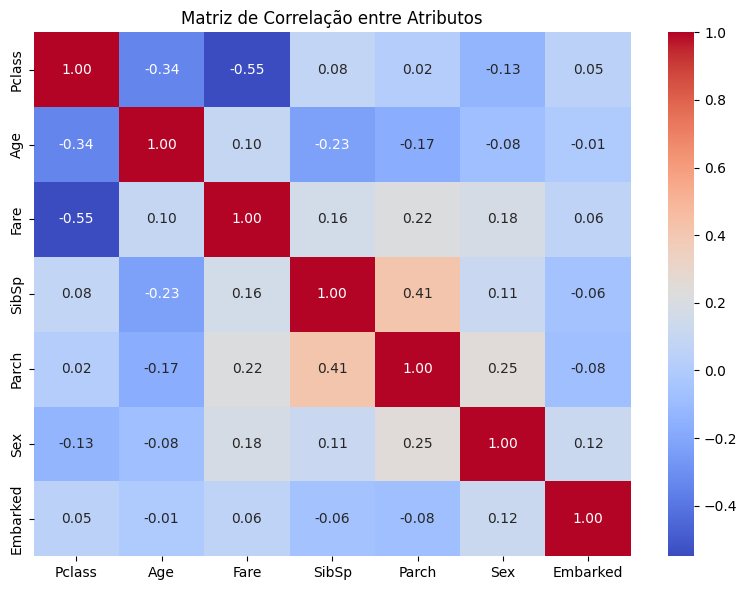


Valores ausentes por coluna:
{'PassengerId': 0, 'Survived': 0, 'Pclass': 0, 'Name': 0, 'Sex': 0, 'Age': 177, 'SibSp': 0, 'Parch': 0, 'Ticket': 0, 'Fare': 0, 'Cabin': 687, 'Embarked': 2}

Balanceamento de classes (Survived):
{'0': 549, '1': 342}

Matriz de correlação entre atributos gerada.

=== Limpeza e Preparação de Dados ===
Features utilizadas (7): ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch', 'Sex', 'Embarked']
Features removidas por alta correlação: []

Aplicando padronização (Standardization)...

=== Treinando MLP ===
Epoch 0: Train Loss 0.6622, Val Loss 0.6531
Epoch 100: Train Loss 0.4409, Val Loss 0.4251
Epoch 200: Train Loss 0.4258, Val Loss 0.4201
Epoch 300: Train Loss 0.4191, Val Loss 0.4163

Acurácia na Validação: 81.56%


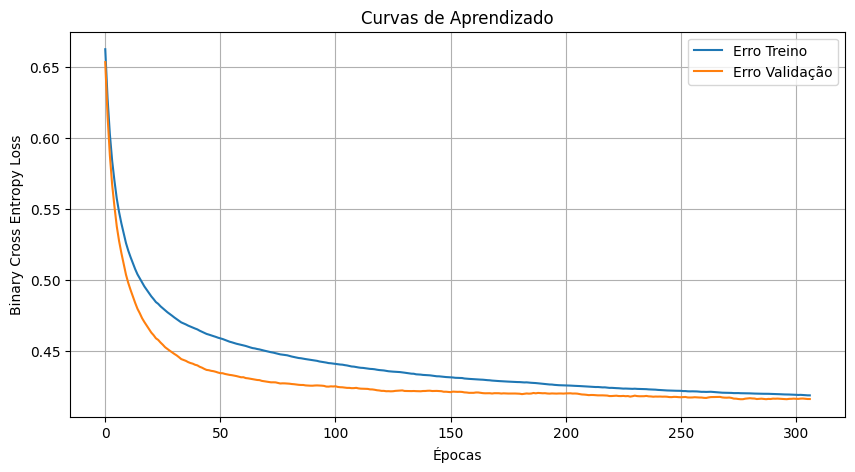

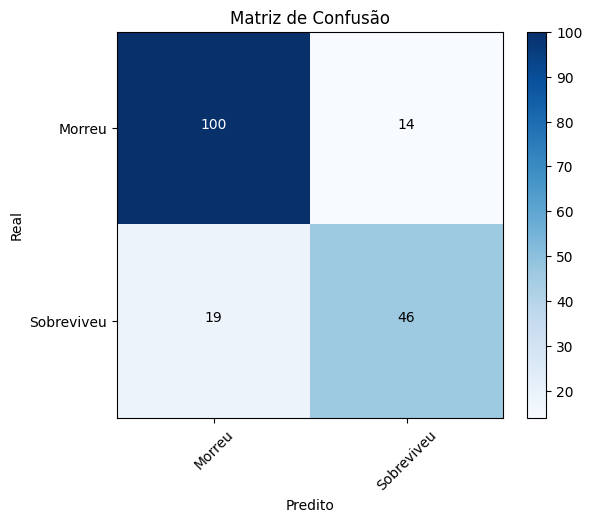

In [59]:
def main():
    print("=== Mineração e Análise de Dados ===")
    mining_report = mine_titanic_data(DATASETS_DIR)
    print("\nValores ausentes por coluna:")
    print(mining_report["missing"])
    print("\nBalanceamento de classes (Survived):")
    print(mining_report["label_balance"])

    print("\nMatriz de correlação entre atributos gerada.")

    print("\n=== Limpeza e Preparação de Dados ===")
    data = clean_titanic_data(DATASETS_DIR)
    X_full = data["X_train"]
    y_full = data["y_train"]
    X_test_kaggle = data["X_test"]
    features = data["feature_names"]

    print(f"Features utilizadas ({len(features)}): {features}")
    print(f"Features removidas por alta correlação: {data['removed_features']}")

    indices = np.random.permutation(X_full.shape[0])
    split_idx = int(X_full.shape[0] * 0.8)
    train_idx, val_idx = indices[:split_idx], indices[split_idx:]

    X_train, y_train = X_full[train_idx], y_full[train_idx]
    X_val, y_val = X_full[val_idx], y_full[val_idx]

    print("\nAplicando padronização (Standardization)...")
    X_train, X_val, X_test_kaggle = standardize(X_train, X_val, X_test_kaggle)

    print("\n=== Treinando MLP ===")
    input_dim = X_train.shape[1]
    mlp = MLPClassifier(input_dim, hidden_dims=[12, 6], output_dim=1, seed=42, dropout_rate=0.2, l2_lambda=1e-3)

    train_losses, val_losses = mlp.fit(X_train, y_train, X_val, y_val,
                                     epochs=2000, lr=0.01, batch_size=32, early_stopping_patience=30, min_delta=1e-4)

    y_pred_val = mlp.predict_classes(X_val)

    acc = np.mean(y_pred_val.flatten() == y_val.flatten())
    print(f"\nAcurácia na Validação: {acc*100:.2f}%")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Erro Treino")
    plt.plot(val_losses, label="Erro Validação")
    plt.xlabel("Épocas")
    plt.ylabel("Binary Cross Entropy Loss")
    plt.title("Curvas de Aprendizado")
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(y_val.flatten(), y_pred_val.flatten())
    plot_confusion_matrix(cm)

if __name__ == "__main__":
    main()
